## B Spline


/home/yip/miniconda3/envs/robotic_course/lib/python3.9/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 1.21.0)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


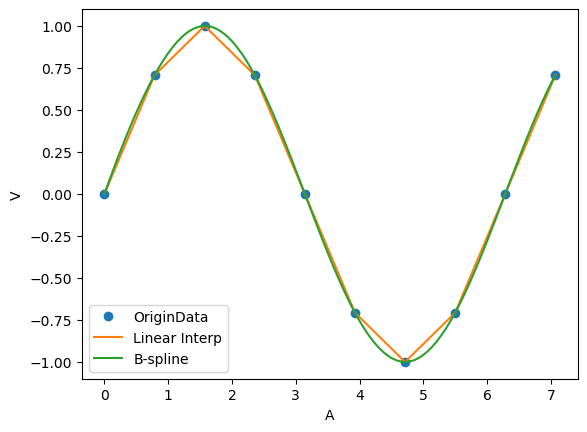

In [2]:
import numpy as np
import pylab as pl
from scipy import interpolate 
import matplotlib.pyplot as plt

x = np.linspace(0, 2*np.pi+np.pi/4, 10)
y = np.sin(x)

x_new = np.linspace(0, 2*np.pi+np.pi/4, 100)
f_linear = interpolate.interp1d(x, y)
tck = interpolate.splrep(x, y)
y_bspline = interpolate.splev(x_new, tck)

plt.xlabel(u'A')
plt.ylabel(u'V')

plt.plot(x, y, "o",  label="OriginData")
plt.plot(x_new, f_linear(x_new), label=u"Linear Interp")
plt.plot(x_new, y_bspline, label=u"B-spline")

pl.legend()
pl.show()

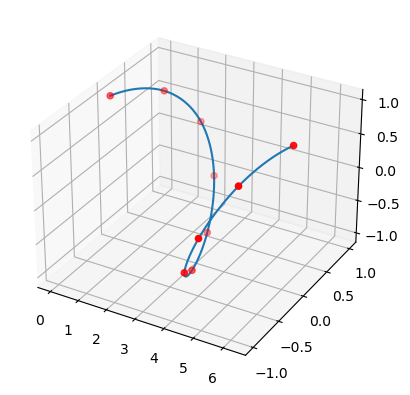

In [3]:
x = np.linspace(0, 2*np.pi, 10)
y = np.array([np.sin(x), np.cos(x)])
# Periodic condition is satisfied because y coordinates of points on the ends are equivalent
ax = plt.axes(projection='3d')
xx = np.linspace(0, 2*np.pi, 100)
bspl = interpolate.make_interp_spline(x, y, k=3, bc_type='periodic', axis=1)
ax.plot3D(xx, *bspl(xx))
ax.scatter3D(x, *y, color='red')
plt.show()

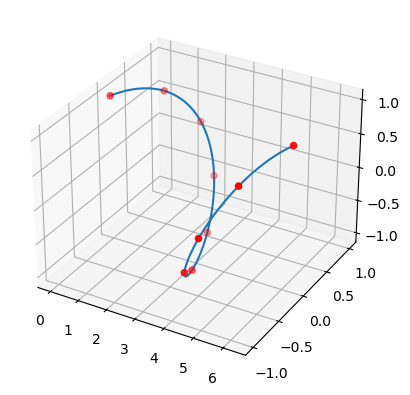

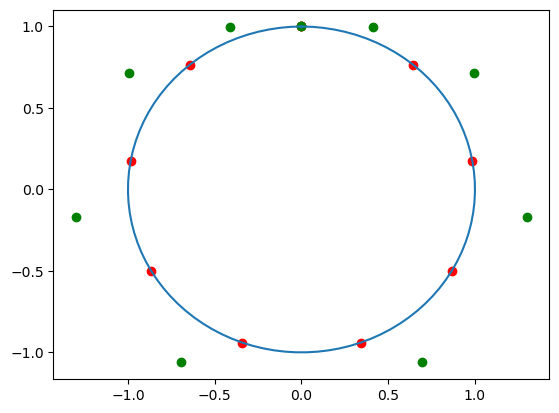

In [4]:
# 2 Dimensional
x_range = 2*np.pi
x = np.linspace(0, x_range, 10)
y = np.array([np.sin(x), np.cos(x)])
# Periodic condition is satisfied because y coordinates of points on the ends are equivalent
ax = plt.axes(projection='3d')
xx = np.linspace(0, x_range, 100)
bspl = interpolate.make_interp_spline(x, y, k=5, bc_type=None, axis=1)
# print(bspl.t, "\n", bspl.c)
# bspl = interpolate.make_interp_spline(x, y, k=3, bc_type="periodic", axis=1)
ax.plot3D(xx, *bspl(xx))
# *y 将把它的元素分别传递给 ax.scatter3D 函数，每个元素将成为一个参数
ax.scatter3D(x, *y, color='red')
plt.show()
plt.plot(bspl(xx)[0], bspl(xx)[1], label="B-spline")
plt.scatter(y[0], y[1], color='red', label="OriginData")
plt.scatter([t[0] for t in bspl.c],[t[1] for t in bspl.c],
            color='green', label="Knots")

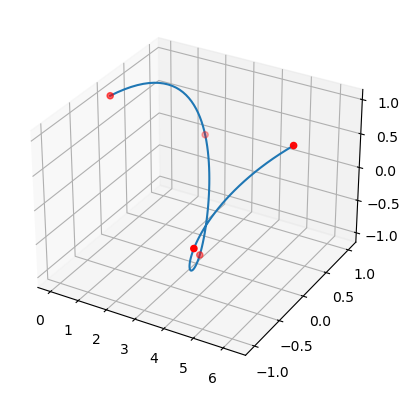

In [5]:
# 3 Dimensional

# Spline gen
x_range = 2*np.pi
x = np.linspace(0, x_range, 5)
y = np.array([x, np.sin(x), np.cos(x)])
# Periodic condition is satisfied because y coordinates of points on the ends are equivalent
ax = plt.axes(projection='3d')
xx = np.linspace(0, x_range, 100)
bspl = interpolate.make_interp_spline(x, y, k=3, bc_type=None, axis=1)
ax.plot3D(*bspl(xx))
ax.scatter3D(*y, color='red')
plt.show()

## Bezier Insertion


In [11]:
import numpy as np
from traj_gen import cubic_bezier_evaluate, bezier_evaluate, cubic_evaluate, BEZIER_MAT, HERMITE_MAT, UNI_B_MAT

### Insert a new knot(evaluated from tk) into Bezier Spline

In [12]:
tk = 0.6
para_mat = BEZIER_MAT
para_inv = np.linalg.inv(para_mat)

# Knot
P1 = np.array([0, 0, 1])
P2 = np.array([0, 1, 0])
P3 = np.array([1, 1, 0])
P4 = np.array([1, 0, 0])
P = np.array([P1, P2, P3, P4])

Pk = cubic_evaluate(P, tk, para_mat)
tk_diag = np.array([[1, 0, 0, 0],[0, tk, 0, 0],[0, 0, tk**2, 0],[0, 0, 0, tk**3]])
print(para_inv @ tk_diag @ para_mat @ P)
print("Pk:", Pk)


[[0.    0.    1.   ]
 [0.    0.6   0.4  ]
 [0.36  0.84  0.16 ]
 [0.648 0.72  0.064]]
Pk: [[0.648 0.72  0.064]]


### Insert a knot into Hermite spline
This is easy because Hermite & Bezier can convert to each other